# 02. PCA, Clustering, Cell-Type Annotation, and Differential Expression

Runs PCA and Leiden clustering on the healthy sample, annotates each cluster with a cell type using published marker genes, then maps the infected sample onto the same cell-type space with `sc.tl.ingest` and runs differential expression (V vs H) within each cell type to identify virus-responsive transporter genes.

**Input**: `dataset/processed/tomato_qc_normalized.h5ad`, `dataset/reference/pce14906-sup-0015-table_s6.xlsx` (marker gene table), `dataset/reference/ITAG4.0_descriptions.txt`

**Output**: `dataset/processed/final_candidates.csv`, `dataset/processed/final_candidates.json`

In [67]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

from kneed import KneeLocator
import matplotlib.pyplot as plt

import json

Batch effects between samples distort clustering when healthy and infected cells are analyzed together. The healthy sample is clustered and annotated first, and the infected sample is later mapped onto this reference space with `sc.tl.ingest`, rather than clustering both jointly.

In [3]:
adata = sc.read_h5ad("../dataset/processed/tomato_qc_normalized.h5ad")
adata_v = adata[adata.obs["sample_no"].isin(["4"])].copy()
adata = adata[adata.obs["sample_no"].isin(["1"])].copy()

## 1) PCA

In [4]:
# seurat_v3 flavor operates on raw counts rather than normalized values, and is recommended for cross-sample HVG selection
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000, 
                            layer="counts", batch_key="sample_no")

adata.var['highly_variable'][adata.var['highly_variable'] == True].count()

np.int64(2000)

In [5]:
sc.tl.pca(adata, use_highly_variable=True)

/home/h/miniconda/envs/tomato-sc/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


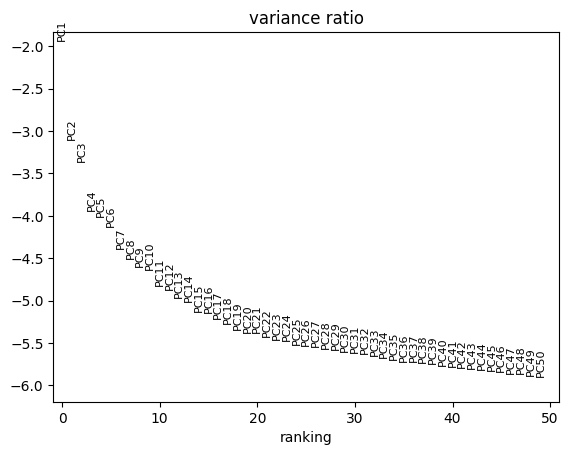

In [6]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [7]:
cumulative_variance = np.cumsum(adata.uns['pca']['variance_ratio'])
n_components = range(1, len(cumulative_variance) + 1)

# Elbow method: pick the number of PCs beyond which additional components add little cumulative explained variance
kl = KneeLocator(
    list(n_components),
    cumulative_variance.tolist(),
    curve="concave",
    direction="increasing",
)

optimal_comp = kl.knee
print(f"Optimal components: {kl.knee}")

Optimal components: 13


## 2) NN

In [8]:
# Number of PCs from the elbow method above is reused as n_neighbors for the KNN graph
sc.pp.neighbors(adata, n_neighbors=optimal_comp)

In [9]:
sc.tl.umap(adata)

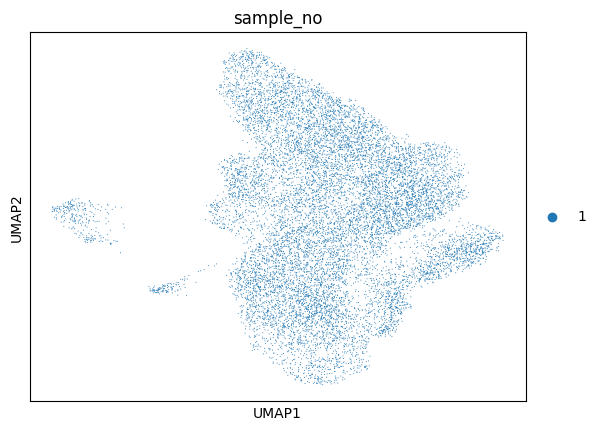

In [10]:
# Check for residual batch structure within the healthy sample before clustering
sc.pl.umap(
    adata,
    color="sample_no",
    size=2,
)

## 3) clustering

In [11]:
# Leiden is used instead of Louvain because it guarantees well-connected communities, 
# avoiding Louvain's known issue of producing internally disconnected clusters
for res in range(1, 10):
    res *= 0.1
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, 
                 flavor="igraph", n_iterations=2)

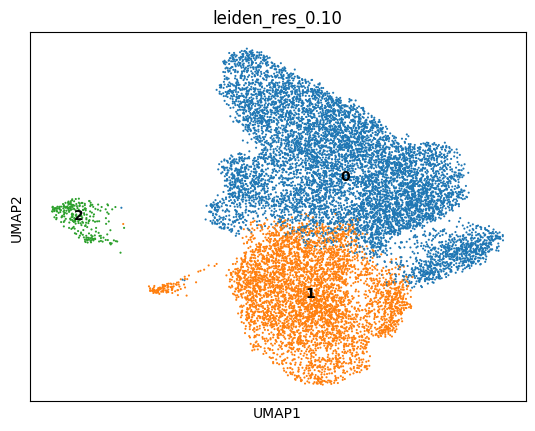

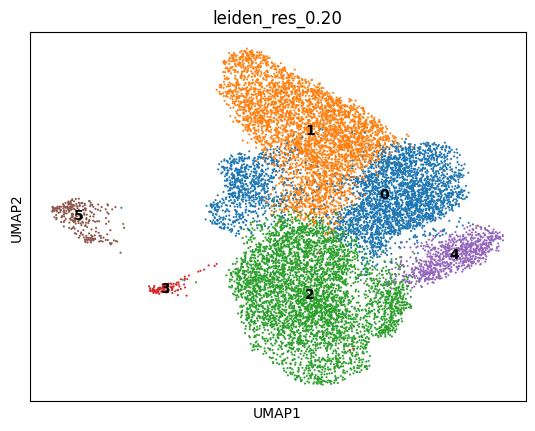

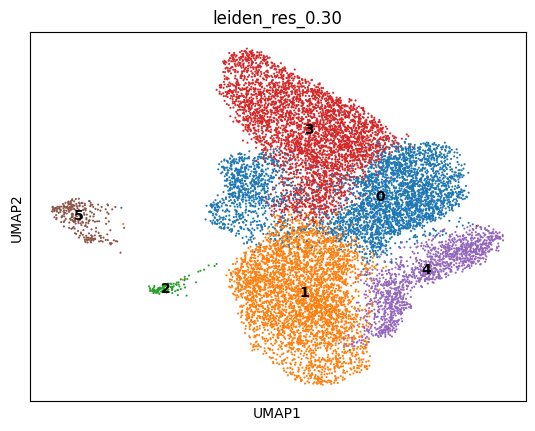

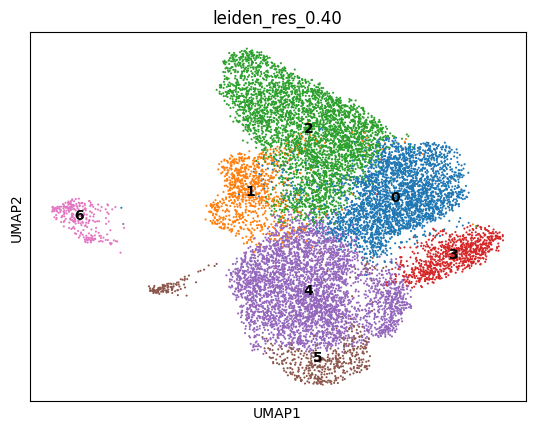

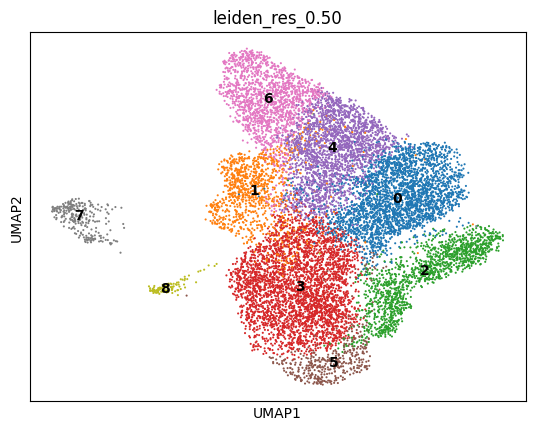

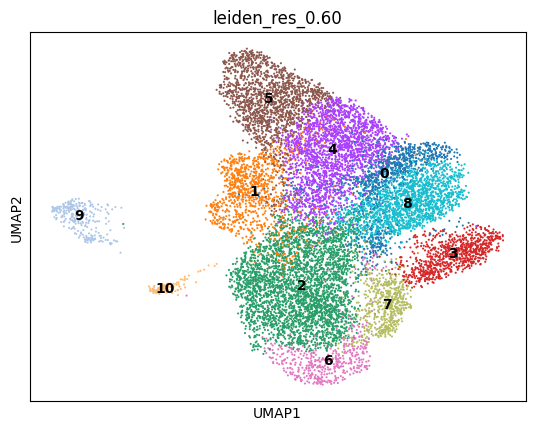

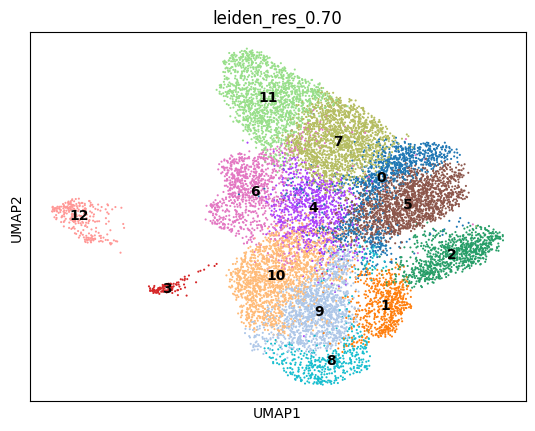

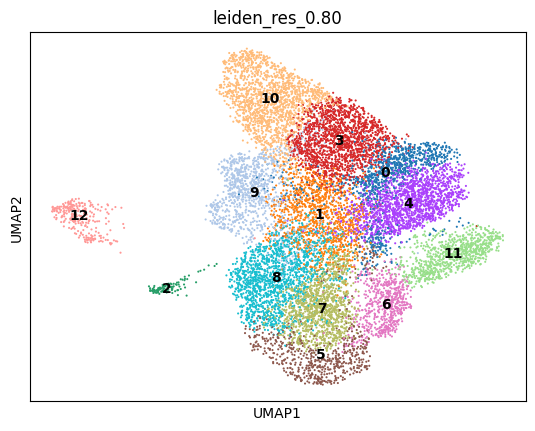

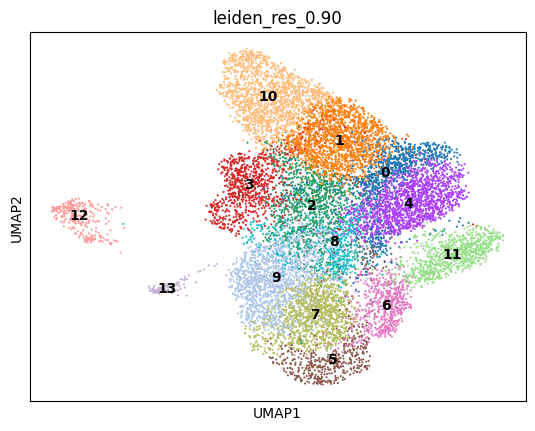

In [12]:
# Scan a range of resolutions to select the one that best separates biologically distinct clusters without over-splitting
for res in range(1, 10):
    res *= 0.1
    sc.pl.umap(
        adata,
        color=[f"leiden_res_{res:4.2f}"],
        legend_loc="on data",
    )

In [25]:
# Resolution 0.6 was selected because it produces a cluster count 
# consistent with the cell types reported in the source publication, 
# rather than the resolution that visually appears cleanest
optimal_res = 0.6

## 4) Cell type annotation(lableing) with marker gene

In [14]:
annotation_info = pd.read_excel(
    "../dataset/reference/pce14906-sup-0015-table_s6.xlsx",
    engine='calamine', header=1
)

marker genes:
- mesophyll: ['CAB1B', 'PNSB4', 'RBCS3b']
- guard: ['MYB306', 'MPK9']
- vascular: ['APL', 'PP2A1', 'ACL5', 'SHR']
- epidermal: ['ATML1', 'GSTT1']

In [15]:
annotation_info

,cell types,gene,pvalue,pct.1,pct.2,padj,baseMean,FoldChange,log2FoldChange,up_down,gene_symbol,gene_description,GO_id,GO_term,KEGG_id,KEGG_description
0,EC,Solyc09g010800.5.1,1.371444e-51,1.000,0.900,4.673471e-47,1.996675,3.884257,1.957639,Up,MTB,Metallothionein-like protein type 2 B,GO:0046872,metal ion binding,NaN,NaN
1,NaN,Solyc01g104740.3,3.500968e-46,0.733,0.079,1.193025e-41,-0.589310,5.951226,2.573187,Up,MBF1C,Multiprotein-bridging factor 1c,"GO:0003700,GO:0003713,GO:0005730,GO:0005737,GO...",DNA-binding transcription factor activity|tran...,NaN,NaN
2,NaN,Solyc08g062437.1,3.311227e-42,0.475,0.010,1.128367e-37,-2.559805,7.539789,2.914524,Up,NaN,17.3 kDa class II heat shock protein,GO:0005737,cytoplasm,sly04141,Protein processing in endoplasmic reticulum
3,NaN,Solyc03g116700.4,1.091264e-40,0.891,0.432,3.718701e-36,1.016864,4.783985,2.258213,Up,NaN,Cucumber peeling cupredoxin,"GO:0009055,GO:0046872",electron transfer activity|metal ion binding,NaN,NaN
4,NaN,Solyc01g106620.2,6.566866e-39,0.396,0.003,2.237791e-34,-3.482275,11.657094,3.543136,Up,NaN,Basic form of pathogenesis-related protein 1,"GO:0005576,GO:0006952,GO:0009607",extracellular region|defense response|response...,"sly04016,sly04075,sly04626",MAPK signaling pathway - plant|Plant hormone s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5267,NaN,Solyc04g071610.4,3.698257e-08,0.120,0.050,1.260255e-03,-2.506738,2.315111,1.211082,Up,ASR1,Abscisic stress-ripening protein 1,"GO:0005622,GO:0005634,GO:0008270,GO:0009414,GO...",intracellular|nucleus|zinc ion binding|respons...,NaN,NaN
5268,NaN,Solyc04g078195.1,2.912571e-07,0.167,0.089,9.925169e-03,-1.872742,2.313465,1.210055,Up,SN1,Snakin-1,"GO:0005576,GO:0005618,GO:0006952",extracellular region|cell wall|defense response,NaN,NaN
5269,NaN,Solyc06g076140.4,7.300090e-06,0.623,0.541,2.487652e-01,0.784538,1.810042,0.856023,Up,NaN,Metallothionein-like protein type 2,GO:0046872,metal ion binding,NaN,NaN
5270,NaN,Solyc04g011390.1,9.331192e-05,0.127,0.075,1.000000e+00,-2.250042,2.976289,1.573515,Up,NaN,Histone H4,"GO:0000786,GO:0003677,GO:0005634,GO:0006334,GO...",nucleosome|DNA binding|nucleus|nucleosome asse...,NaN,NaN


In [16]:
# Marker gene symbols reported in the reference cell-type study, mapped to tomato gene IDs via exact symbol match
gene_symbols = ['CAB1B', 'PNSB4', 'RBCS3b', 'MYB306', 'MPK9', 'APL', 'PP2A1', 'ACL5', 'SHR', 'ATML1', 'GSTT1']
id_map = dict()

annotation_info["gene_symbol"] = annotation_info["gene_symbol"].str.strip().str.upper()

for g in gene_symbols:
    matches = annotation_info[annotation_info["gene_symbol"] == g.upper()]
    if len(matches) == 0:
        id_map[g] = []
        continue
    id_map[g] = matches["gene"].unique().tolist()

id_map

{'CAB1B': ['Solyc02g071030.2',
  'Solyc02g070940.1',
  'Solyc02g071000.1',
  'Solyc02g071010.1'],
 'PNSB4': ['Solyc12g036170.2'],
 'RBCS3b': [],
 'MYB306': ['Solyc03g116100.3'],
 'MPK9': ['Solyc12g040680.2', 'Solyc04g007710.3'],
 'APL': [],
 'PP2A1': ['Solyc02g069030.3'],
 'ACL5': [],
 'SHR': [],
 'ATML1': [],
 'GSTT1': ['Solyc12g056250.2']}

In [17]:
desc = pd.read_csv("../dataset/reference/ITAG4.0_descriptions.txt",
                  sep="\t", header=None, names=["gene_id", "description"])
desc

,gene_id,description
0,Solyc00g500001.1,Retrovirus-related Pol polyprotein from transp...
1,Solyc00g500002.1,Retrovirus-related Pol polyprotein from transp...
2,Solyc00g500003.1,MP domain-containing protein (AHRD V3.3 *-* A0...
3,Solyc00g500004.1,Unknown protein
4,Solyc00g500005.1,Unknown protein
...,...,...
34070,Solyc12g100330.2,cytosine-5 DNA methyltransferase3L
34071,Solyc12g100340.1,serine/arginine-rich SC35-like splicing factor...
34072,Solyc12g100360.1,calpain-type cysteine protease DEK1 (AHRD V3.3...
34073,Solyc12g100363.1,Unknown protein


In [18]:
# Some marker symbols have no exact match in the annotation table, 
# so functional description keywords are used as a fallback to recover their tomato gene IDs.
keyword_map = {
    "RBCS3b": r"ribulose bisphosphate carboxylase small chain",
    "APL":    r"altered phloem development",
    "ACL5":   r"acaulis|thermospermine synthase",
    "SHR":    r"short-root|short root",
    "ATML1":  r"meristem layer 1|protodermal factor",
}

for symbol, pattern in keyword_map.items():
    matches = desc[desc["description"].str.contains(pattern, case=False, regex=True, na=False)]
    id_map[symbol] = matches["gene_id"].unique().tolist()

id_map

{'CAB1B': ['Solyc02g071030.2',
  'Solyc02g070940.1',
  'Solyc02g071000.1',
  'Solyc02g071010.1'],
 'PNSB4': ['Solyc12g036170.2'],
 'RBCS3b': ['Solyc02g085940.4', 'Solyc07g017950.3'],
 'MYB306': ['Solyc03g116100.3'],
 'MPK9': ['Solyc12g040680.2', 'Solyc04g007710.3'],
 'APL': [],
 'PP2A1': ['Solyc02g069030.3'],
 'ACL5': [],
 'SHR': [],
 'ATML1': ['Solyc07g055950.3', 'Solyc10g007800.3', 'Solyc12g011010.2'],
 'GSTT1': ['Solyc12g056250.2']}

In [19]:
marker_genes_symbols = {
    "mesophyll": ['CAB1B', 'PNSB4', 'RBCS3b'],
    "guard": ['MYB306', 'MPK9'],
    "vascular": ['APL', 'PP2A1', 'ACL5', 'SHR'],
    "epidermal": ['ATML1', 'GSTT1']
}

marker_genes = {}
for cell_type, symbols in marker_genes_symbols.items():
    ids = []
    for symbol in symbols:
        ids.extend(id_map.get(symbol, []))
    marker_genes[cell_type] = ids

marker_genes

{'mesophyll': ['Solyc02g071030.2',
  'Solyc02g070940.1',
  'Solyc02g071000.1',
  'Solyc02g071010.1',
  'Solyc12g036170.2',
  'Solyc02g085940.4',
  'Solyc07g017950.3'],
 'guard': ['Solyc03g116100.3', 'Solyc12g040680.2', 'Solyc04g007710.3'],
 'vascular': ['Solyc02g069030.3'],
 'epidermal': ['Solyc07g055950.3',
  'Solyc10g007800.3',
  'Solyc12g011010.2',
  'Solyc12g056250.2']}

In [20]:
def relabel_dotplot_xaxis(axes_dict, id_to_symbol):
    """
    Replace gene ID tick labels on a Scanpy dotplot with their marker gene symbols, for readability.

    Args:
        axes_dict (dict): axes dictionary returned by sc.pl.dotplot(..., show=False)
        id_to_symbol (dict): mapping from gene ID to marker gene symbol

    Returns:
        None (modifies the plot axes in place)
    """
    ax = axes_dict["mainplot_ax"]
    new_labels = [
        id_to_symbol.get(label.get_text().replace("gene:", ""), label.get_text())
        for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(new_labels)

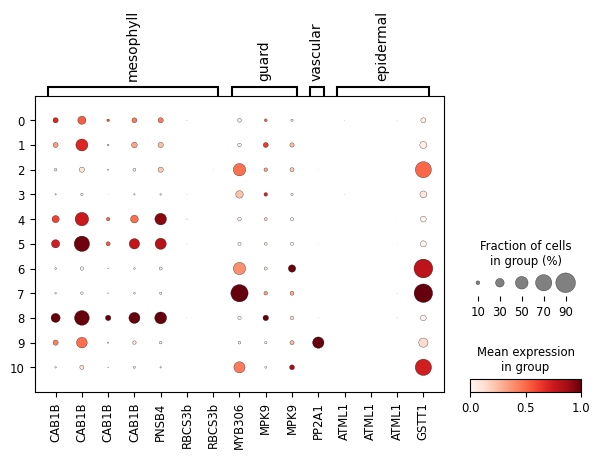

In [26]:
id_to_symbol = {}
for symbol, ids in id_map.items():
    for gid in ids:
        id_to_symbol[gid] = symbol

axes_dict_1 = sc.pl.dotplot(
    adata, marker_genes, groupby=f"leiden_res_{optimal_res:4.2f}",
    standard_scale="var", show=False
)
relabel_dotplot_xaxis(axes_dict_1, id_to_symbol)
plt.show()

In [27]:
sc.tl.rank_genes_groups(adata, groupby=f"leiden_res_{optimal_res:4.2f}", method="wilcoxon")

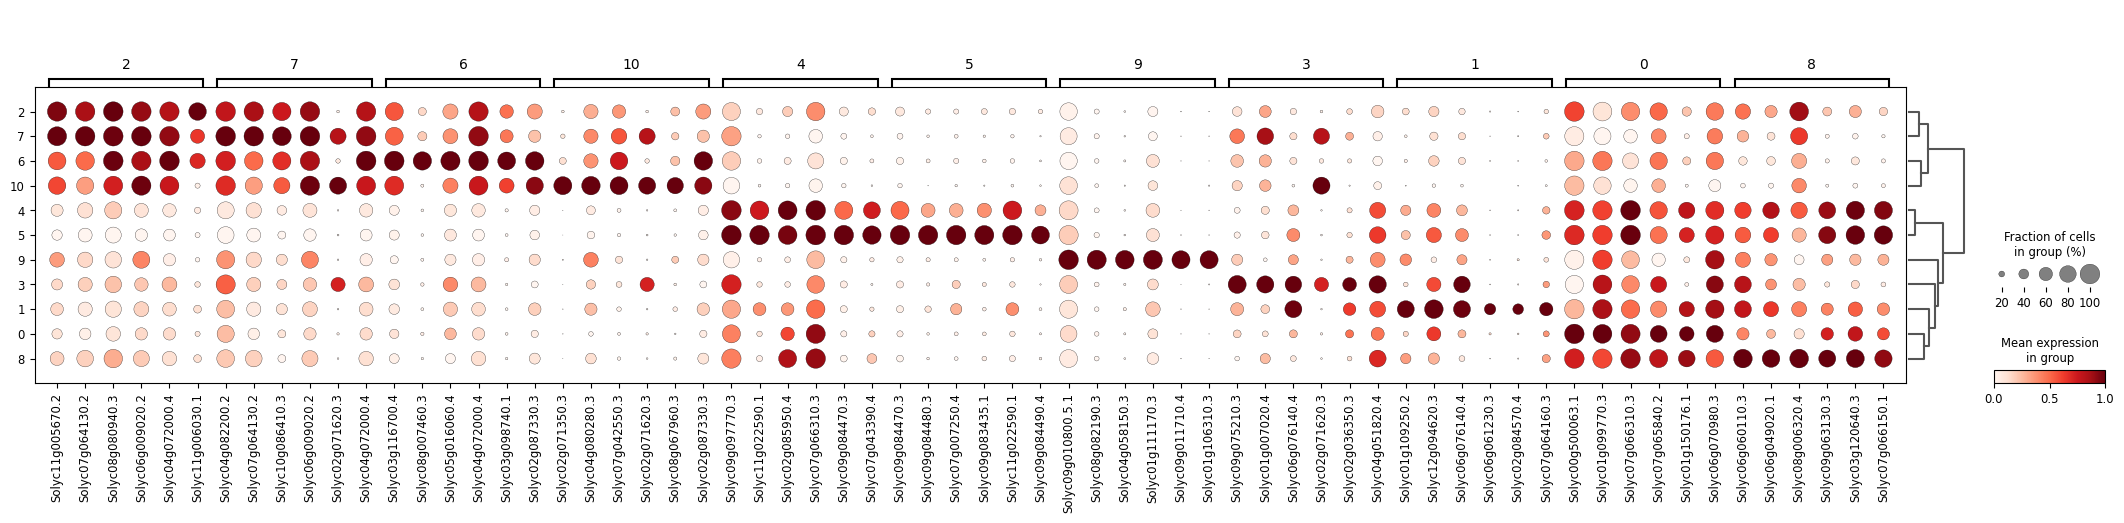

In [28]:
sc.pl.rank_genes_groups_dotplot(adata, groupby=f"leiden_res_{optimal_res:4.2f}", 
                                standard_scale="var", n_genes=6)

In [29]:
desc_lookup = desc.set_index("gene_id")["description"]

cluster_col = f"leiden_res_{optimal_res:4.2f}"
clusters = adata.obs[cluster_col].cat.categories

# Cross-reference each cluster's top marker genes against their ITAG4.0 functional descriptions to support cell-type annotation.
top_markers = {}
for cl in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cl).head(10)
    df["role"] = df["names"].map(desc_lookup)
    top_markers[cl] = df

for cl, df in top_markers.items():
    print(f"=== cluster {cl} ===")
    print(df[["names", "logfoldchanges", "pvals_adj", "role"]].to_string(index=False))
    print()

=== cluster 0 ===
           names  logfoldchanges     pvals_adj                                                                              role
Solyc00g500063.1        1.249802 4.527406e-138    Ribulose bisphosphate carboxylase large chain (AHRD V3.3 *** A0A2G2Z7Q2_CAPAN)
Solyc01g099770.3        0.801407 8.314372e-113                                      meloidogyne-induced giant cell protein DB141
Solyc07g066310.3        1.032863  1.570549e-82 Photosystem II 10 kDa polypeptide, chloroplastic (AHRD V3.3 *** A0A2G3C3G4_CAPCH)
Solyc07g065840.2        0.866693  8.163919e-75                                                       molecular chaperone Hsp90-2
Solyc01g150176.1        1.379587  1.955465e-60                    Gibberellin regulated protein (AHRD V3.3 *** A0A200Q364_9MAGN)
Solyc06g070980.3        0.686026  2.490537e-54                     Ubiquitin-conjugating enzyme (AHRD V3.3 *** A0A200QF19_9MAGN)
Solyc00g500027.1        0.951287  2.028064e-50                                 

Based on the marker gene dotplot and top differentially expressed genes per cluster, clusters are assigned to cell types as follows: 
mesophyll (0, 1, 4, 8), Guard cell (7, confirmed), Vascular (6, 10), Epidermal (2, 3, 5), Unknown (9). 

The infected sample is mapped onto this cell-type space next.

In [30]:
adata.obs["cell_type"] = adata.obs[f"leiden_res_{optimal_res:4.2f}"].map(
    {
        "0": "Mesophyll",
        "1": "Mesophyll",
        "4": "Mesophyll",
        "8": "Mesophyll",
        "7": "Guard cell",
        "6": "Vascular",
        "10": "Vascular",
        "2": "Epidermal",
        "3": "Epidermal",
        "5": "Epidermal",
        "9": "Unknown",
    }
)

## 5. ingest

In [36]:
# Projects the infected sample onto the healthy sample's PCA/UMAP space and transfers cell-type labels via KNN, 
# avoiding batch-effect distortion from joint clustering
sc.tl.ingest(adata_v, adata, obs="cell_type")

/home/h/miniconda/envs/tomato-sc/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [37]:
adata_v.obs["cell_type"]

AAACCCACAGAAGCTG-4    Mesophyll
AAACCCAGTACTGGGA-4    Mesophyll
AAACCCAGTCAGTCCG-4    Mesophyll
AAACCCAGTCGCTTAA-4    Epidermal
AAACCCAGTCTGATAC-4     Vascular
                        ...    
TTTGTTGCAGCTATTG-4    Mesophyll
TTTGTTGCAGCTTCCT-4    Epidermal
TTTGTTGCAGTCCCGA-4    Mesophyll
TTTGTTGTCCTTCTGG-4    Epidermal
TTTGTTGTCGGACGTC-4    Mesophyll
Name: cell_type, Length: 9370, dtype: category
Categories (5, object): ['Epidermal', 'Guard cell', 'Mesophyll', 'Unknown', 'Vascular']

In [38]:
adata_v.obs["cell_type"].value_counts()

cell_type
Mesophyll     5022
Epidermal     3821
Vascular       351
Guard cell     121
Unknown         55
Name: count, dtype: int64

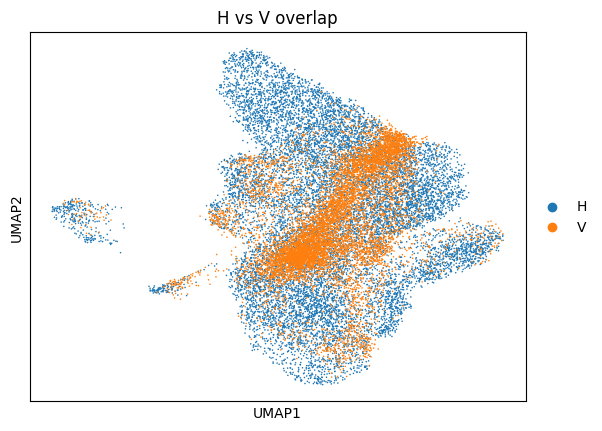

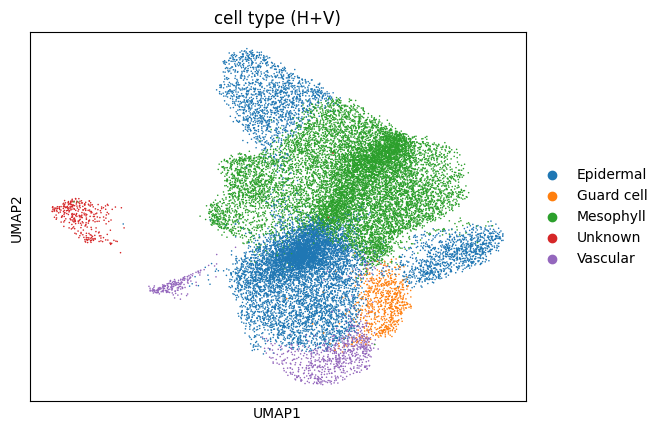

origin             H         V
cell_type                     
Epidermal   0.433252  0.407791
Guard cell  0.044780  0.012914
Mesophyll   0.457670  0.535966
Unknown     0.019596  0.005870
Vascular    0.044703  0.037460


In [41]:
adata.obs["origin"] = "H"
adata_v.obs["origin"] = "V"

adata_combined = ad.concat([adata, adata_v], join="outer")

# Sanity checks on the ingest result before proceeding to differential expression

# 1. Overlap in same cell type
sc.pl.umap(adata_combined, color="origin", size=5, title="H vs V overlap")
# 2. Distribution by cell type
sc.pl.umap(adata_combined, color="cell_type", size=5, title="cell type (H+V)")
# 3. cell type x origin by number
import pandas as pd
print(pd.crosstab(adata_combined.obs["cell_type"], adata_combined.obs["origin"], normalize="columns"))

## 6) DEG

In [57]:
cell_types = adata_combined.obs["cell_type"].values.unique().tolist()
p_value = 0.05
min_lfc = 0.58

deg_results = {}

# Testing within each cell type separately, rather than across the pooled dataset, 
# avoids confounding differential expression with differences in cell-type composition between samples
for cell in cell_types:
    target = adata_combined[adata_combined.obs["cell_type"] == cell].copy()
    sc.tl.rank_genes_groups(target, groupby="origin", groups=["V"], reference="H", method="wilcoxon")
    df = sc.get.rank_genes_groups_df(target, group="V",
                                           pval_cutoff=p_value, log2fc_min=min_lfc)
    deg_results[cell] = df

for cell, df in deg_results.items():
    print(f"=== {cell} ===")
    print(df.head())

=== Mesophyll ===
              names     scores  logfoldchanges  pvals  pvals_adj
0  Solyc04g025530.3  69.566055        4.000401    0.0        0.0
1  Solyc03g116700.4  67.076561        3.438768    0.0        0.0
2  Solyc01g104740.3  65.301521        3.947104    0.0        0.0
3  Solyc08g007460.3  60.449532        4.909332    0.0        0.0
4  Solyc08g062437.1  57.215122        5.117314    0.0        0.0
=== Vascular ===
              names     scores  logfoldchanges          pvals      pvals_adj
0  Solyc08g062437.1  24.259403        6.386503  5.261630e-130  1.792901e-125
1  Solyc01g104740.3  23.947294        4.618079  9.859940e-127  1.679887e-122
2  Solyc06g036290.3  23.490259        4.114414  5.129884e-122  5.826693e-118
3  Solyc08g078700.2  23.371592        4.316239  8.314619e-121  7.083016e-117
4  Solyc03g007890.3  22.910429        4.829015  3.657218e-116  2.137472e-112
=== Guard cell ===
              names     scores  logfoldchanges         pvals     pvals_adj
0  Solyc01g104740.3

In [59]:
desc_lookup = desc.set_index("gene_id")["description"]

# Restrict DEGs to transporter-related genes, the functional category of interest for this study
transporter_pattern = r"transporter|carrier|channel|efflux|symporter|antiporter|ATPase"

filtered_results = {}

for cell, df in deg_results.items():
    df = df.copy()
    df["description"] = df["names"].str.replace("gene:", "", regex=False).map(desc_lookup)
    transporter_hits = df[df["description"].str.contains(transporter_pattern, case=False, regex=True, na=False)]
    filtered_results[cell] = transporter_hits

for cell, df in filtered_results.items():
    print(f"=== {cell} ===")
    print(df[["names", "logfoldchanges", "pvals_adj", "description"]].to_string(index=False))
    print()

=== Mesophyll ===
           names  logfoldchanges     pvals_adj                                                                                   description
Solyc03g097840.3        3.892665  0.000000e+00                     Phosphate carrier protein, mitochondrial (AHRD V3.3 *** A0A2G3A0N1_CAPAN)
Solyc10g055740.2        3.820880  0.000000e+00                          lysine histidine transporter-like 8 (AHRD V3.3 *** A0A2I4HTG9_9ROSI)
Solyc10g078930.2        3.035903 1.522262e-216 Activator of 90 kDa heat shock protein ATPase-like protein 1 (AHRD V3.3 *** A0A1J3GDI7_NOCCA)
Solyc06g009290.4        2.217925 6.238475e-133                              ABC transporter B family member (AHRD V3.3 *** A0A2K3NLX3_TRIPR)
Solyc09g075820.3        1.661248 1.233134e-131                                                                   Sugar transporter protein 2
Solyc02g093860.3        2.539726 1.756590e-131                          Lysine histidine transporter-like 1 (AHRD V3.3 *** A0A1U8FZ64_CA

In [66]:
combined_df = pd.concat(
    [df.assign(cell_type=cell) for cell, df in filtered_results.items()],
    ignore_index=True
)

# Excludes the Unknown cluster and counts how many cell types each gene appears differentially expressed in, 
# to prioritize cell-type-specific responses over broadly expressed ones
known_df = combined_df[combined_df["cell_type"] != "Unknown"]
gene_summary = known_df.groupby("names")["cell_type"].agg(
    n_cell_types="nunique",
    cell_types=lambda x: ", ".join(sorted(set(x)))
)

# Genes differentially expressed in at most 2 cell types are kept as candidates
specific_genes = gene_summary[gene_summary["n_cell_types"] <= 2].index
specific_df = combined_df[combined_df["names"].isin(specific_genes)].merge(
    gene_summary, on="names"
)

for cell in specific_df["cell_type"].unique():
    print(f"=== {cell} ===")
    sub = specific_df[specific_df["cell_type"] == cell].sort_values("logfoldchanges", ascending=False)
    print(sub[["names", "logfoldchanges", "pvals_adj", "description", "n_cell_types", "cell_types"]].to_string(index=False))
    print()

=== Mesophyll ===
           names  logfoldchanges     pvals_adj                                                                                description  n_cell_types           cell_types
Solyc05g006020.3        7.455045  4.176399e-02                        Nucleobase-ascorbate transporter 8 (AHRD V3.3 *** A0A1U8EN63_CAPAN)             1            Mesophyll
Solyc02g092450.3        3.237723  1.787920e-02                               Calcium-transporting ATPase (AHRD V3.3 *** A0A2G2XH12_CAPBA)             1            Mesophyll
Solyc01g104780.3        2.703435  1.972270e-05                    Vacuolar iron transporter-like protein (AHRD V3.3 *** A0A2K3NGY4_TRIPR)             2 Epidermal, Mesophyll
Solyc02g082450.3        2.163782  3.950407e-08                                      Auxin efflux carrier (AHRD V3.3 *** A0A200PYL2_9MAGN)             2 Epidermal, Mesophyll
Solyc01g086730.4        1.856287  2.946511e-86                     magnesium transporter%2C putative (DUF803) (AHRD V

In [68]:
# Manually curated shortlist per cell type: 
# putative/"-like" annotated genes excluded, prioritized by logFC, favoring transporters with clearly resolved function; 
# ABC transporter family genes were included given their known role in plant defense responses
target_genes = {
    "mesophyll": ["Solyc05g006020.3", "Solyc02g092450.3", "Solyc02g082450.3", "Solyc05g006640.4"],
    "vascular": ["Solyc11g062020.2", "Solyc10g051120.3", "Solyc01g106900.3"],
    "guard": ["Solyc09g082890.2", "Solyc07g063520.3"],
    "epidermal": ["Solyc09g065560.3", "Solyc05g009020.4", "Solyc05g051220.3", 
                  "Solyc01g006150.3", "Solyc01g105450.4", "Solyc09g075020.3"]    
}

# target_genes id list: {cell_type: [id, id, ...]}
selected_ids = set()
for ids in target_genes.values():
    selected_ids.update(ids)

combined_with_summary = combined_df.merge(gene_summary, on="names")

# extract (description, logFC, pvals_adj, n_cell_types, cell_types) of target genes
final_candidates = combined_with_summary[
    combined_with_summary["names"].isin(selected_ids)
][["names", "logfoldchanges", "pvals_adj", "description", "n_cell_types", "cell_types"]].drop_duplicates(subset="names")

id_to_selected_celltype = {}
for cell, ids in target_genes.items():
    for gid in ids:
        id_to_selected_celltype.setdefault(gid, []).append(cell)

final_candidates["selected_as"] = final_candidates["names"].map(id_to_selected_celltype)

# save as csv
final_candidates.to_csv("../dataset/processed/final_candidates.csv", index=False)

# save as json(gene_id as key)
final_dict = final_candidates.set_index("names").to_dict(orient="index")
with open("../dataset/processed/final_candidates.json", "w") as f:
    json.dump(final_dict, f, indent=2, default=str)